# Hotel Reviews Analysis

Using Agoda reviews, perform sentiment analysis to determine general opinion of hotel's customers. 
Additionally, determine key strengths and weaknesses of the business by using the following:

- N-grams
- CountVectorizer
- TF-IDF Vectorizer
- Sentiment Analysis
- LDA

Optional
- K-Means Clustering

In [310]:
#!pip install matplotlib
#!pip install seaborn
#!pip install nltk
#!pip install advertools
#!pip install emoji
#!pip install scikit-llm
#!pip install openai
#!pip install WordCloud
#!pip install sentence-transformers

  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached cuda_bindings-13.2.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.3 kB)
  Using cached nvidia_cudnn_cu13-9.19.0.56-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.0-py3-none-manylinux2014_x86_64.whl

In [28]:
# loading libraries
import json
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

import nltk
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import string
import advertools
import os
from collections import Counter


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#from sentence_transformers import SentenceTransformer

import emoji
import pickle
from dotenv import load_dotenv
from wordcloud import WordCloud

# Libraries for skllm setup
import openai
from skllm.config import SKLLMConfig

# Libraries for modeling
from skllm.models.gpt.classification.zero_shot import ZeroShotGPTClassifier
from skllm.models.gpt.classification.zero_shot import MultiLabelZeroShotGPTClassifier

### create a new column detailing the possible problems in the business
from openai import OpenAI
import json
import ast

nltk.download('vader_lexicon')
nltk.download('punkt_tab') # Downloads the Punkt tokenizer models
nltk.download('stopwords') # Downloads the list of stopwords
nltk.download('wordnet') # Downloads the WordNet lemmatizer data
nltk.download('averaged_perceptron_tagger_eng') # Downloads the POS tagger model

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/maxmin2127/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/maxmin2127/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/maxmin2127/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/maxmin2127/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/maxmin2127/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/maxmin2127/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
# Libraries for skllm setup
import openai
from skllm.config import SKLLMConfig

# Libraries for modeling
from skllm.models.gpt.classification.zero_shot import ZeroShotGPTClassifier
from skllm.models.gpt.classification.zero_shot import MultiLabelZeroShotGPTClassifier

In [4]:
# set up constants
BASE_PATH = "."

TEAL   = '#1D9E75'
NAVY   = '#0D1B2A'
WINDOW_GREY = '#9DA1AA'
BLUE   = '#378ADD'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
AMBER  = '#BA7517'
TRAFFIC_PURPLE = "#A03472"
FLAME_RED = "#AF2B1E"
CLUSTER_COLORS = [TEAL, BLUE, CORAL, PURPLE, AMBER, '#639922', '#D4537E', '#888780', '#E24B4A', '#5DCAA5']

In [5]:
load_dotenv()

True

## Step 1: Load Dataset

In [6]:
with open(f"{BASE_PATH}/hotel_reviews.json", "r") as file:
    reviews = json.load(file)

In [7]:
# get filtered reviews and set to a dataframe
target_keys = ["id", "createdAt", "language", "comments"]
reviews_json = list(map(
    lambda review: {key: review[key] for key in target_keys if key in review}, 
    reviews
))

In [8]:
reviews_df = pd.DataFrame(reviews_json).sort_values(by = "createdAt", ascending = True).reset_index(drop = True)
reviews_df.head()

,id,createdAt,language,comments
0,452366754,2019-05-13T07:38:29Z,en,Very accommodating receptionists. Host was res...
1,455669196,2019-05-20T06:33:29Z,en,The place is affordable yet very comfortable a...
2,457374586,2019-05-24T08:12:24Z,en,:: Great service and clean quality rooms<br/>:...
3,457824254,2019-05-25T07:16:26Z,en,We had a very nice stay. The place is a bit fa...
4,463237102,2019-06-03T06:07:33Z,en,"New, clean and affordable. Pictures posted are..."


## Step 3: Exploratory Data Analysis

In [9]:
# date
reviews_df['createdAt'] = pd.to_datetime(reviews_df['createdAt'])
reviews_df['month'] = reviews_df['createdAt'].dt.month
reviews_df['year'] = reviews_df['createdAt'].dt.year

/tmp/ipykernel_76859/3044168989.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  yearly['year'] = yearly['createdAt'].dt.to_period('Y')
2026-04-19 12:30:07,568 | INFO | category.py:224 | update | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-19 12:30:07,572 | INFO | category.py:224 | update | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


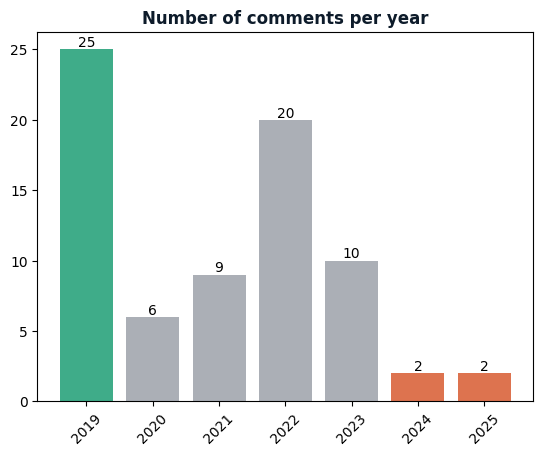

In [10]:
yearly = reviews_df.dropna(subset=['createdAt']).copy()
yearly['year'] = yearly['createdAt'].dt.to_period('Y')
yearly_counts = yearly['year'].value_counts().sort_index()

colors = [TEAL if x == max(yearly_counts) 
          else (
              CORAL if x in yearly_counts.nsmallest(2).values
              else WINDOW_GREY
            )
            for x in yearly_counts
        ]

plt.bar([str(m) for m in yearly_counts.index], yearly_counts.values, color=colors, alpha=0.85)
plt.title('Number of comments per year', fontsize=12, fontweight='bold', color=NAVY)
for i, v in enumerate(yearly_counts.values):
    plt.text(i,v + 0.2, str(v), ha='center', fontsize=10)
plt.xticks(rotation=45)

plt.show()

_The reviews from Agoda website fluctuates after 2022. This could be an indication that Agoda may not be the recent website customers visit in the past three years_

In [11]:
# month
MONTHS = {
    1: "January", 
    2: "February", 
    3: "March", 
    4: "April", 
    5: "May", 
    6: "June", 
    7: "July", 
    8: "August", 
    9: "September", 
    10: "October", 
    11: "November", 
    12: "December"
}

by_month_df = reviews_df.groupby("month")["id"].count().reset_index()

In [247]:
monthly = reviews_df.dropna(subset=['createdAt']).copy()
monthly['month'] = reviews_df['createdAt'].dt.month
monthly_counts = monthly['month'].value_counts().sort_index()

colors = [TEAL if x in monthly_counts.nlargest(2).values
          else (
              CORAL if x in monthly_counts.nsmallest(2).values
              else WINDOW_GREY
            )
            for x in monthly_counts
        ]

2026-04-19 10:53:33,559 | INFO | category.py:224 | update | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-19 10:53:33,565 | INFO | category.py:224 | update | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


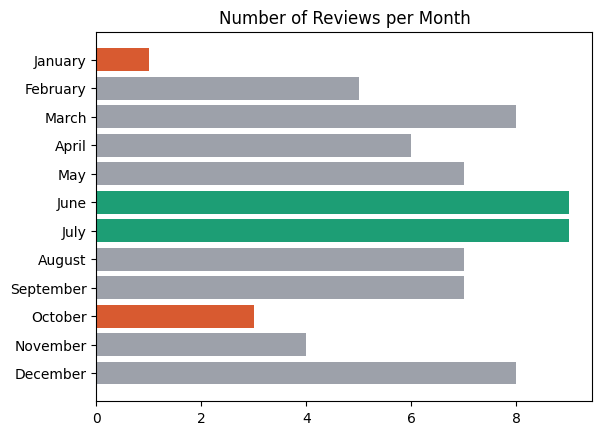

In [248]:
plt.barh(
    by_month_df['month'].map(MONTHS), 
    by_month_df['id'], color = colors)
plt.gca().invert_yaxis() # Inverts y-axis
plt.title("Number of Reviews per Month")
plt.show()

_Mapping the review count per month reveals that most posters tend to post their reviews around the summer months(June and July), which could be an indication that those are the peak months for tourists. On the other hand, the non-holiday seasons like January and October are the weakest months for tourists._ 

## Step 2 : Perform Sentiment Analysis

In [249]:
api_key = os.getenv("OPEN_AI_KEY")
SKLLMConfig.set_openai_key(api_key)

In [250]:
''' For sentiment (Positive, Negative, Neutral) analysis.
# Fit the classifier with the classes you're interested in
clf.fit(None, ['Positive', 'Neutral', 'Negative'])
labels = clf.predict(reviews_df['comments'])
reviews_df['sentiment'] = labels
'''

" For sentiment (Positive, Negative, Neutral) analysis.\n# Fit the classifier with the classes you're interested in\nclf.fit(None, ['Positive', 'Neutral', 'Negative'])\nlabels = clf.predict(reviews_df['comments'])\nreviews_df['sentiment'] = labels\n"

In [251]:
# Determine whether a comment carries underlying problems
clf = ZeroShotGPTClassifier(model='gpt-4o')

clf.fit(None, ['Has problems', 'No problems'])
has_problems_labels = clf.predict(reviews_df['comments'])

100%|██████████| 74/74 [01:50<00:00,  1.49s/it]


In [252]:
reviews_df['has_problems'] = [1 if p == "Has problems" else 0 for p in has_problems_labels]

2026-04-19 10:55:38,823 | INFO | category.py:224 | update | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-19 10:55:38,826 | INFO | category.py:224 | update | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


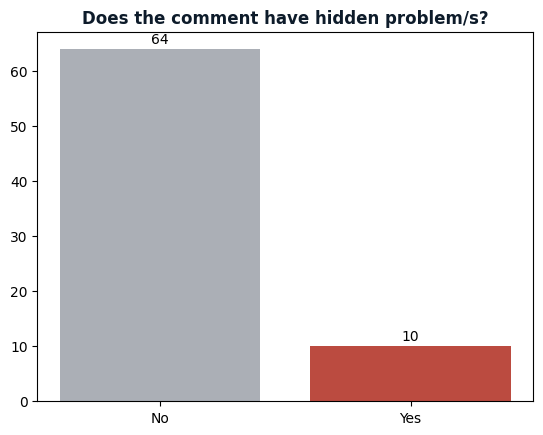

In [253]:
# Show problem distribution
problematic_counts = reviews_df['has_problems'].astype(str).value_counts()
problematic_colors_map = dict(zip(problematic_counts.index, [WINDOW_GREY, FLAME_RED]))
plt.bar(problematic_counts.index, 
        problematic_counts.values,
        color=[problematic_colors_map[l] for l in problematic_counts.index], alpha=0.85)
plt.title('Does the comment have hidden problem/s?', fontsize=12, fontweight='bold', color=NAVY)
for i, v in enumerate(problematic_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.xticks((0, 1), ("No", "Yes"))

plt.show()

## Get only the problems in the problematic comments

In [255]:
### create a new column detailing the possible problems in the business
from openai import OpenAI
client = OpenAI(api_key=api_key)

In [193]:
# get problematic comments
# problematic_df = reviews_df[reviews_df["has_problems"] == "Has problems"]

In [257]:
def determine_problems(comment):
  prompt = f"""
  # Context
  I am trying to find out underlying problems in a hotel using scraped negative comments, but most of these comments has combined positive remarks. 

  # Your Task
  1. Assess the comment for any possible problems
  2. Return only the string of problem in English, and a consolidated list


  ## Reminders
    - **Observe proper json format** (double quotes for property name, comma delimiter, etc)
    - **DO NOT HALLUCINATE**
    - There can be multiple problems in one comment, just separate the problems with a comma
    
  # Post Details
  - Comment: {comment}

  # Expected Output: A json of this format:
  {{
    'problem': str, 
    'problems_lst': str[]
  }}
  """

  response = client.responses.create(
      model = "gpt-5.4-mini",
      input = prompt
  )

  try:
    output = json.loads(response.output_text)
  except Exception as e:
    print(f"Error: {e}")
    output = {
        "problem": "", 
        "problems_lst": []
    }

  return output["problem"], output["problems_lst"]

In [261]:
def add_problems_column(row):
  '''
  Input: Accepts a pd.DataFrame row
  Output: Updated pd.DataFrame row with new AI generated columns

  What it does: Creates a new column with the problems found on the comment list.
  '''
  problem = row["comments"]
  problems_lst = []
  if row["has_problems"]:
    problem, problems_lst = determine_problems(row["comments"])

  print(row.name, " -> ", row["id"])
  row["comments.altered"] = problem
  row["problems"] = problems_lst
  return row

In [262]:
# apply to the entire dataframe
reviews_df = reviews_df.apply(add_problems_column, axis = 1)

0  ->  452366754
1  ->  455669196
2  ->  457374586


2026-04-19 10:58:15,404 | INFO | _client.py:1025 | _send_single_request | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


3  ->  457824254
4  ->  463237102
5  ->  464978113
6  ->  466151217
7  ->  470170791
8  ->  478463023
9  ->  487255672
10  ->  489038494


2026-04-19 10:58:17,154 | INFO | _client.py:1025 | _send_single_request | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


11  ->  493116126
12  ->  497940741
13  ->  499763972
14  ->  504554564
15  ->  505820800
16  ->  510284316
17  ->  524444143
18  ->  525566371
19  ->  527036713
20  ->  536108843


...

69  ->  1048911330264828254


2026-04-19 10:58:29,753 | INFO | _client.py:1025 | _send_single_request | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


70  ->  1204026847348563739
71  ->  1317872227434669373


2026-04-19 10:58:31,551 | INFO | _client.py:1025 | _send_single_request | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


72  ->  1530241864451930367
73  ->  1558492482008537834


In [263]:
reviews_df.head()

,id,createdAt,language,comments,month,year,has_problems,comments.altered,problems
0,452366754,2019-05-13 07:38:29+00:00,en,Very accommodating receptionists. Host was res...,5,2019,0,Very accommodating receptionists. Host was res...,[]
1,455669196,2019-05-20 06:33:29+00:00,en,The place is affordable yet very comfortable a...,5,2019,0,The place is affordable yet very comfortable a...,[]
2,457374586,2019-05-24 08:12:24+00:00,en,:: Great service and clean quality rooms<br/>:...,5,2019,0,:: Great service and clean quality rooms<br/>:...,[]
3,457824254,2019-05-25 07:16:26+00:00,en,We had a very nice stay. The place is a bit fa...,5,2019,1,"Far from town proper, hard to hail a taxi or t...","[Far from town proper, Hard to hail a taxi or ..."
4,463237102,2019-06-03 06:07:33+00:00,en,"New, clean and affordable. Pictures posted are...",6,2019,0,"New, clean and affordable. Pictures posted are...",[]


In [264]:
def get_current_timestamp():
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d_%H%M%S")
    return timestamp

In [265]:
os.makedirs(f"{BASE_PATH}/outputs", exist_ok = True)
path = f"{BASE_PATH}/outputs/reviews-{get_current_timestamp()}.csv"
reviews_df.to_csv(path)
print(f"reviews_df saved in {path}!")

reviews_df saved in ./outputs/reviews-20260419_105840.csv!


## Step 2: Preprocessing of Comments
- Removing Stopwords and Punctuation

In [267]:
# remove unnecessary html tags
tags = ["<br/>", "::", "'s", '\'', '`', '’']
punctuations = list(string.punctuation)
to_remove = tags + punctuations

def remove_tags(text):
    # remove unnecessary words
    matches = [w for w in to_remove if w in text]
    for match in matches:
        text = text.replace(match, " ")
    
    # remove emojis
    return emoji.replace_emoji(text, replace='').lower()
    
reviews_df["comments_cleaned"] = reviews_df["comments.altered"].apply(remove_tags)

In [268]:
# tokenize the text
def tokenize_text(text):
    return word_tokenize(text)

reviews_df["tokens"] = reviews_df["comments_cleaned"].apply(tokenize_text)

In [269]:
# handle stop words
english_stopwords = stopwords.words("english")
tagalog_stopwords = list(advertools.stopwords["tagalog"])
custom_stopwords = [
    "yet", "u", "caused", '\'', 'could', 'can', 'every', 'although', 
    "also", "tapos"
]
final_stopwords = english_stopwords + tagalog_stopwords + custom_stopwords

In [270]:
# remove punctuations
def remove_stopwords_punctuation_noise(tokens):
    return [
        word for word in tokens 
        if word.lower() not in final_stopwords 
        and word not in string.punctuation
    ]

# Apply noise removal
reviews_df['tokens_no_stopwords'] = reviews_df['tokens'].apply(
    remove_stopwords_punctuation_noise
)

In [271]:
# lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

reviews_df['comments_cleaned.tokens'] = reviews_df['tokens_no_stopwords'].apply(lemmatize_tokens)

In [272]:
reviews_df.head()

,id,createdAt,language,comments,month,year,has_problems,comments.altered,problems,comments_cleaned,tokens,tokens_no_stopwords,comments_cleaned.tokens
0,452366754,2019-05-13 07:38:29+00:00,en,Very accommodating receptionists. Host was res...,5,2019,0,Very accommodating receptionists. Host was res...,[],very accommodating receptionists host was res...,"[very, accommodating, receptionists, host, was...","[accommodating, receptionists, host, responsiv...","[accommodating, receptionist, host, responsive..."
1,455669196,2019-05-20 06:33:29+00:00,en,The place is affordable yet very comfortable a...,5,2019,0,The place is affordable yet very comfortable a...,[],the place is affordable yet very comfortable a...,"[the, place, is, affordable, yet, very, comfor...","[place, affordable, comfortable, clean]","[place, affordable, comfortable, clean]"
2,457374586,2019-05-24 08:12:24+00:00,en,:: Great service and clean quality rooms<br/>:...,5,2019,0,:: Great service and clean quality rooms<br/>:...,[],great service and clean quality rooms very...,"[great, service, and, clean, quality, rooms, v...","[great, service, clean, quality, rooms, hospit...","[great, service, clean, quality, room, hospita..."
3,457824254,2019-05-25 07:16:26+00:00,en,We had a very nice stay. The place is a bit fa...,5,2019,1,"Far from town proper, hard to hail a taxi or t...","[Far from town proper, Hard to hail a taxi or ...",far from town proper hard to hail a taxi or t...,"[far, from, town, proper, hard, to, hail, a, t...","[far, town, proper, hard, hail, taxi, tricycle...","[far, town, proper, hard, hail, taxi, tricycle..."
4,463237102,2019-06-03 06:07:33+00:00,en,"New, clean and affordable. Pictures posted are...",6,2019,0,"New, clean and affordable. Pictures posted are...",[],new clean and affordable pictures posted are...,"[new, clean, and, affordable, pictures, posted...","[new, clean, affordable, pictures, posted, acc...","[new, clean, affordable, picture, posted, accu..."


In [273]:
# save as csv
reviews_df
reviews_df = reviews_df[[
            "id", 
            "createdAt", 
            "language", 
            "comments", 
            "comments_cleaned", 
            "comments_cleaned.tokens", 
            "problems",
            "has_problems"
        ]]
os.makedirs(f"{BASE_PATH}/outputs", exist_ok = True)
reviews_df.to_csv(f"{BASE_PATH}/outputs/reviews.csv")
print(f"reviews_df saved in {BASE_PATH}/outputs/reviews.csv!")

reviews_df saved in ./outputs/reviews.csv!


In [274]:
def save_pkl_obj(data, filepath):
  with open(filepath, "wb") as file:
    pickle.dump(data, file)
    print(f"Saved obj in filepath!")

# save stopwords
save_pkl_obj(final_stopwords, f"{BASE_PATH}/outputs/custom_stopwords.pkl")

Saved obj in filepath!


## a. N-grams

In [275]:
all_tokens = [tok for tokens in reviews_df['comments_cleaned.tokens'] for tok in tokens]

In [276]:
def get_ngram_freq(tokens, n, top_k=15):
    return Counter(ngrams(tokens, n)).most_common(top_k)

def plot_ngrams(freq_list, title, color=TEAL):
    labels = [' '.join(gram) for gram, _ in freq_list]
    counts = [count for _, count in freq_list]
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(labels[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', color=NAVY)
    ax.bar_label(bars, padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

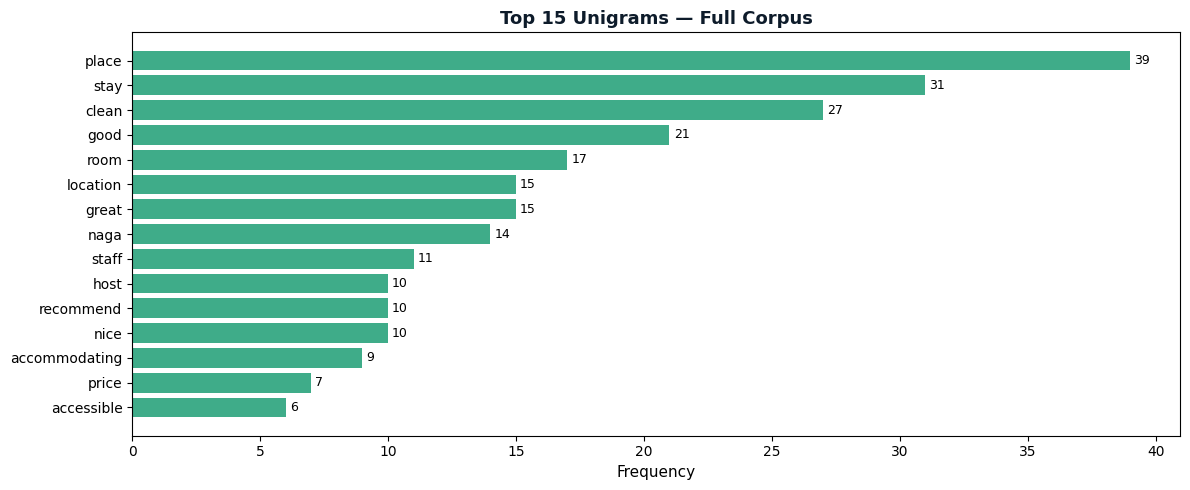

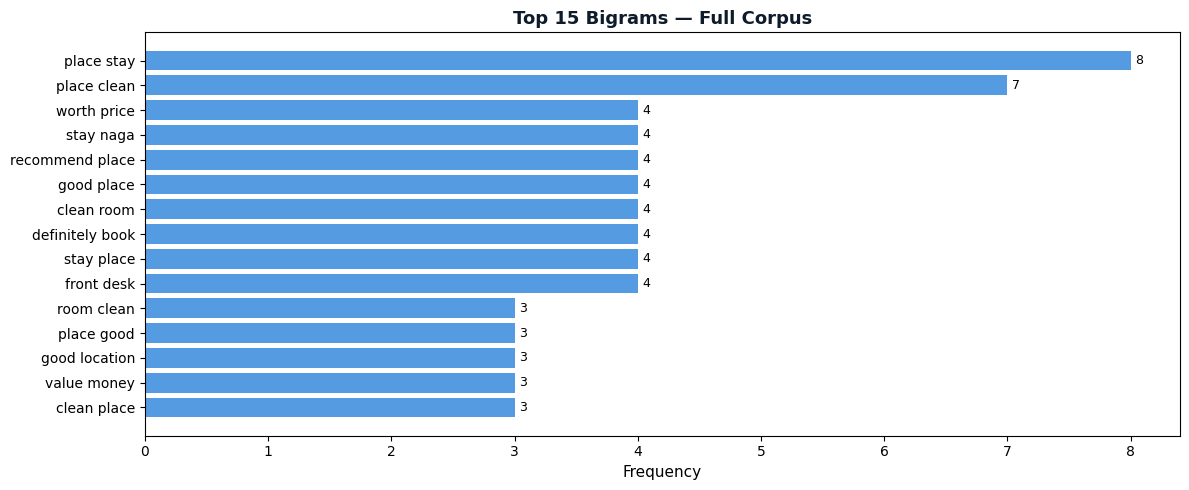

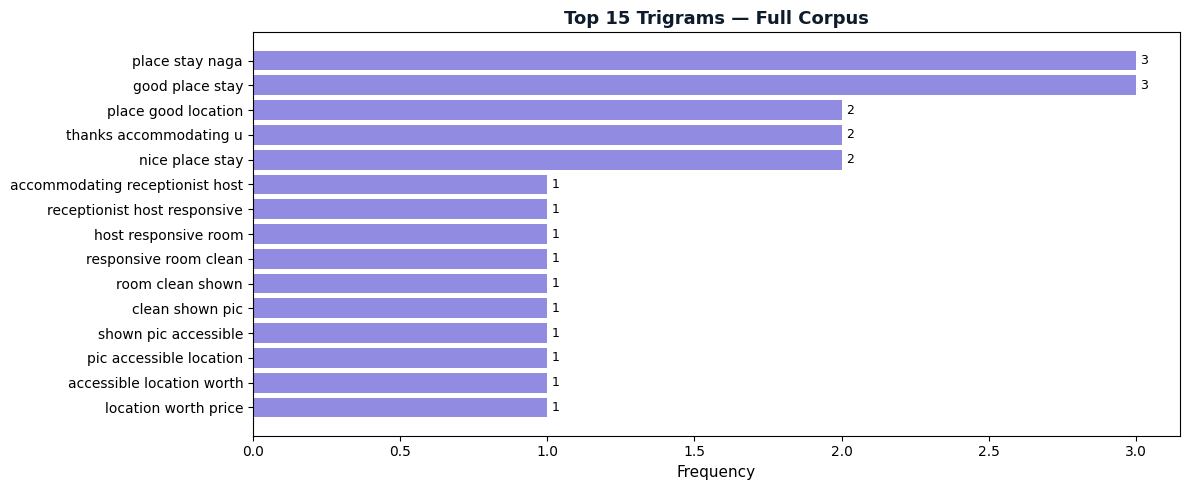

In [277]:
## N-grams for general dataset
plot_ngrams(get_ngram_freq(all_tokens, 1), 'Top 15 Unigrams — Full Corpus', color=TEAL)
plot_ngrams(get_ngram_freq(all_tokens, 2), 'Top 15 Bigrams — Full Corpus',  color=BLUE)
plot_ngrams(get_ngram_freq(all_tokens, 3), 'Top 15 Trigrams — Full Corpus', color=PURPLE)

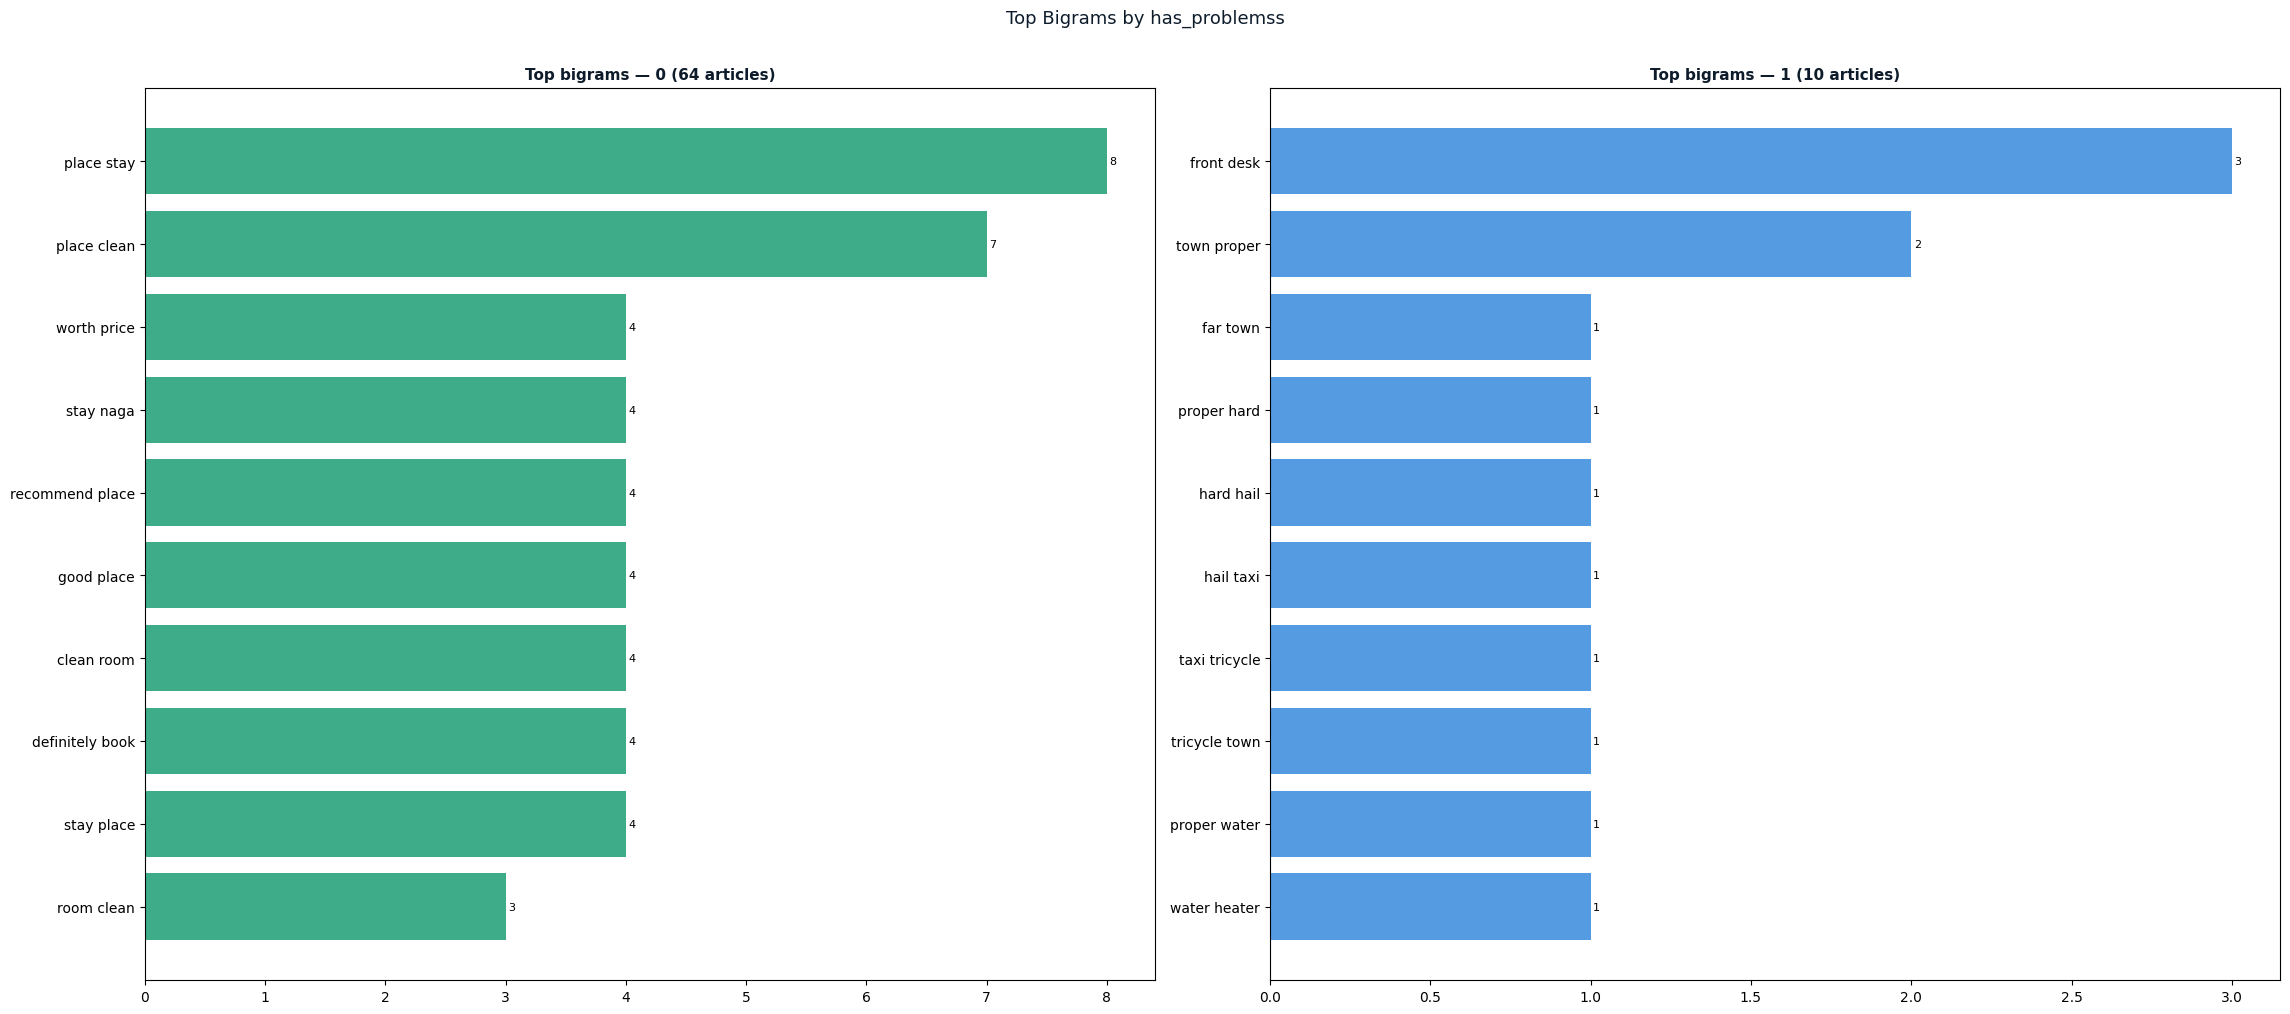

In [278]:
## N-Grams per has_problems
has_problems = reviews_df['has_problems'].unique()
fig, axes = plt.subplots(1, 2, figsize=(23, 10))

has_problems_counts = reviews_df['has_problems'].value_counts()
has_problems_colors_map = dict(zip(has_problems_counts.index, [TEAL, BLUE]))

for ax, has_problems in zip(axes.flatten(), has_problems):
    tokens = [tok for tokens in reviews_df[reviews_df['has_problems'] == has_problems]['comments_cleaned.tokens'] for tok in tokens]
    top_bi = get_ngram_freq(tokens, 2, top_k=10)
    labels = [' '.join(g) for g, _ in top_bi]
    counts = [c for _, c in top_bi]
    bars = ax.barh(labels[::-1], counts[::-1], color=has_problems_colors_map.get(has_problems, TEAL), alpha=0.85)
    ax.set_title(f'Top bigrams — {has_problems} ({len(reviews_df[reviews_df["has_problems"]==has_problems]):,} articles)',
                 fontsize=11, fontweight='bold', color=NAVY)
    ax.bar_label(bars, padding=2, fontsize=8)

plt.suptitle('Top Bigrams by has_problemss', fontsize=13, y=1.01, color=NAVY)
plt.tight_layout()
plt.show()

## b. Vectorizer

In [280]:
# Use full content column; drop empty rows
corpus_df = reviews_df[reviews_df['comments_cleaned'].str.strip() != ''].copy().reset_index(drop=True)
corpus = corpus_df['comments_cleaned'].tolist()
print(f'Corpus size: {len(corpus):,} comments')

Corpus size: 73 comments


In [281]:
tfidf_vec = TfidfVectorizer(
    stop_words=final_stopwords, 
    max_features=5000, 
    ngram_range=(1, 2), 
    min_df=2
)
tfidf_matrix = tfidf_vec.fit_transform(corpus)

tfidf_term_means = pd.Series(
    tfidf_matrix.toarray().mean(axis=0),
    index=tfidf_vec.get_feature_names_out()
).sort_values(ascending=False)

print(f'TF-IDF: {tfidf_matrix.shape[0]:,} comments × {tfidf_matrix.shape[1]:,} terms')
print('\nTop 10 by mean TF-IDF score:')
print(tfidf_term_means.head(10))

TF-IDF: 73 comments × 155 terms

Top 10 by mean TF-IDF score:
stay        0.089085
place       0.086542
clean       0.080774
good        0.074005
great       0.062362
location    0.051861
room        0.045556
price       0.040817
nice        0.039351
naga        0.039056
dtype: float64


Text(0.5, 0, 'Mean TF-IDF Score')

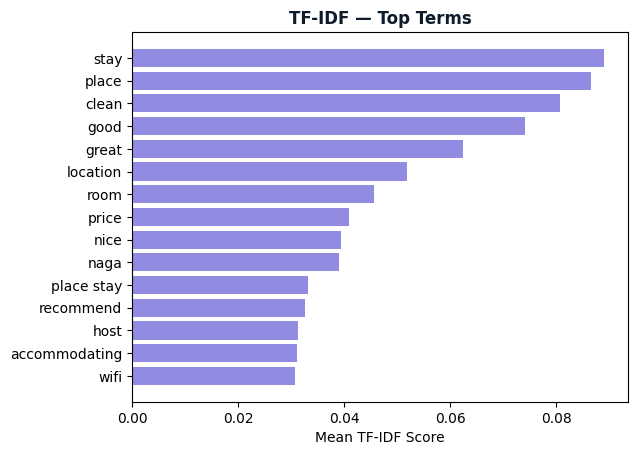

In [282]:
top_tfidf = tfidf_term_means.head(15)
plt.barh(top_tfidf.index[::-1], top_tfidf.values[::-1], color=PURPLE, alpha=0.85)
plt.title('TF-IDF — Top Terms', fontsize=12, fontweight='bold', color=NAVY)
plt.xlabel('Mean TF-IDF Score')

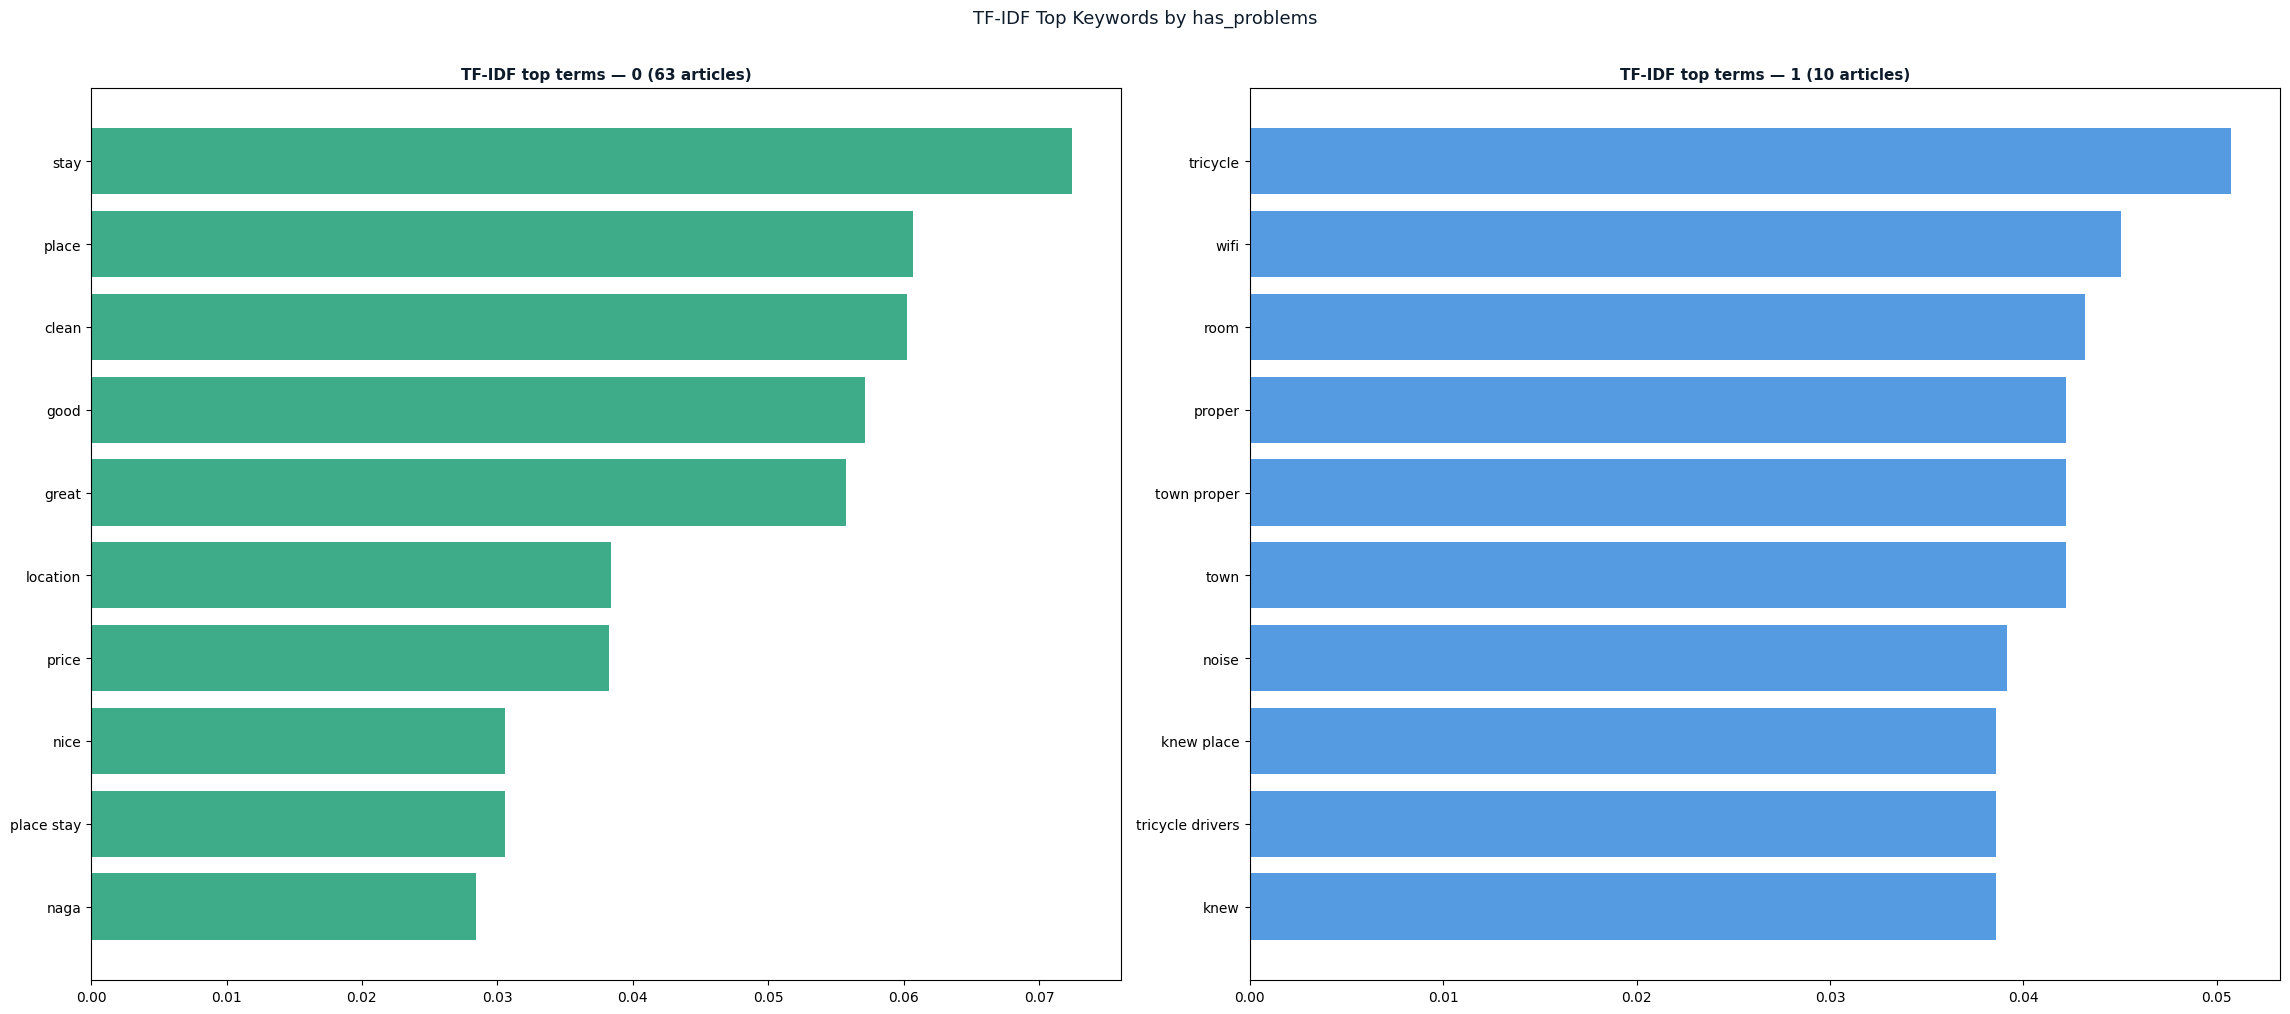

In [283]:
## Per has_problems
fig, axes = plt.subplots(1, 2, figsize=(23, 10))

for ax, has_problems in zip(axes.flatten(), corpus_df['has_problems'].unique()):
    has_problems_corpus = corpus_df[corpus_df['has_problems'] == has_problems]['comments_cleaned'].tolist()
    if len(has_problems_corpus) < 5:
        ax.set_visible(False)
        continue
    vec = TfidfVectorizer(stop_words=final_stopwords, max_features=1000, ngram_range=(1, 2))
    mat = vec.fit_transform(has_problems_corpus)
    scores = pd.Series(mat.toarray().mean(axis=0), index=vec.get_feature_names_out())
    top = scores.sort_values(ascending=False).head(10)
    ax.barh(top.index[::-1], top.values[::-1],
            color=has_problems_colors_map.get(has_problems, TEAL), alpha=0.85)
    ax.set_title(f'TF-IDF top terms — {has_problems} ({len(has_problems_corpus):,} articles)',
                 fontsize=11, fontweight='bold', color=NAVY)

plt.suptitle('TF-IDF Top Keywords by has_problems', fontsize=13, y=1.01, color=NAVY)
plt.tight_layout()
plt.show()

## Get word cloud

In [14]:
def get_word_cloud(df, col_name):
    word_lists = [word_list for word_list in list(df[col_name])]
    all_words = " ".join([word for sublist in word_lists for word in sublist])

    wordcloud = WordCloud(width=800, height=400,
                      random_state=21,
                      max_font_size=110,
                      background_color='white',
                      stopwords=final_stopwords).generate(all_words)
    return wordcloud

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

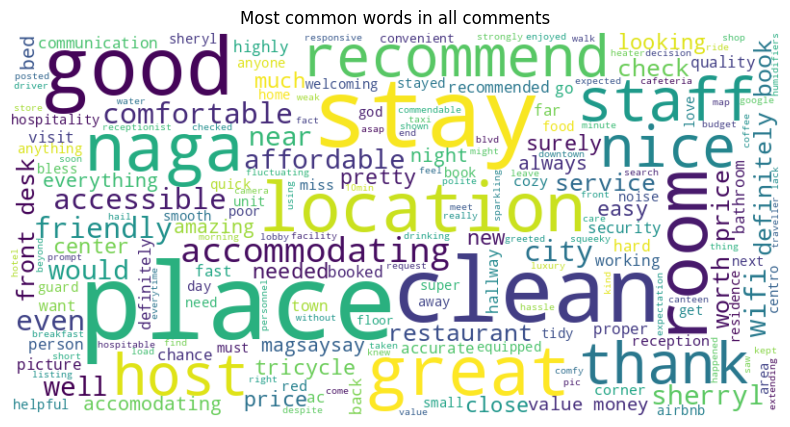

In [285]:
## for general dataframe
all_wordcloud = get_word_cloud(reviews_df, "comments_cleaned.tokens")
# plot the WordCloud image
plt.figure(figsize=(10, 5))
plt.title("Most common words in all comments")
plt.imshow(all_wordcloud, interpolation="bilinear")
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

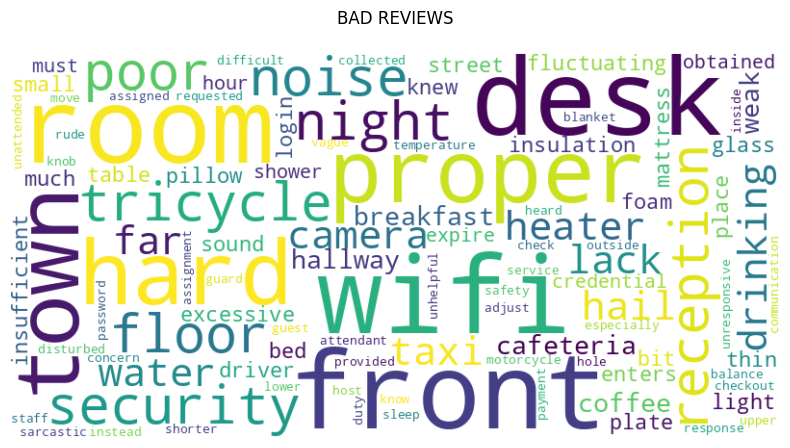

In [286]:
# for bad comments
bad_reviews = reviews_df[reviews_df["has_problems"] == 1]
bad_wordcloud = get_word_cloud(bad_reviews, "comments_cleaned.tokens")
# plot the WordCloud image
plt.figure(figsize=(10, 5))
plt.title("BAD REVIEWS\n")
plt.imshow(bad_wordcloud, interpolation="bilinear")
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

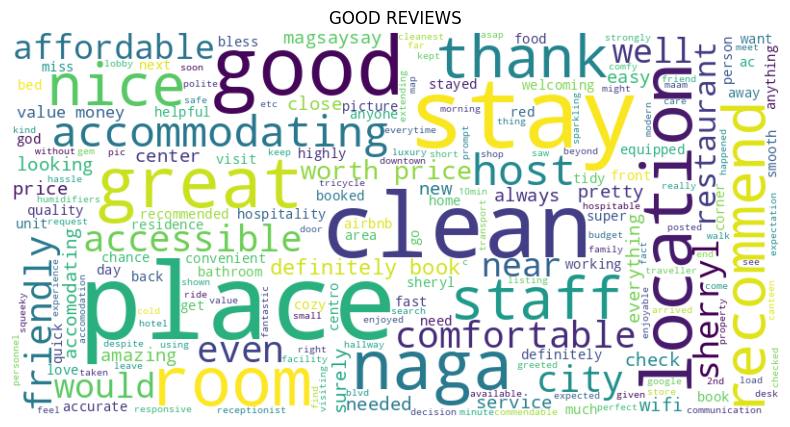

In [220]:
# for good comments
good_reviews = reviews_df[reviews_df["has_problems"] == 0]
good_wordcloud = get_word_cloud(good_reviews, "comments_cleaned.tokens")
# plot the WordCloud image
plt.figure(figsize=(10, 5))
plt.title("GOOD REVIEWS")
plt.imshow(good_wordcloud, interpolation="bilinear")
plt.axis('off')

---

## Targeting Problems

In [16]:
def load_pkl_object(filepath):
    with open(filepath, "rb") as file:
        data = pickle.load(file)
        print(f"Loaded obj from {filepath}!")
        return data

In [19]:
# Load objects
reviews_df = pd.read_csv(f"{BASE_PATH}/outputs/reviews.csv", index_col=0)
custom_stopwords = load_pkl_object(f"{BASE_PATH}/outputs/custom_stopwords.pkl")
problems_df = pd.read_csv(f"{BASE_PATH}/outputs/problems.csv", index_col=0)
problem_clusters_df = pd.read_csv(f"{BASE_PATH}/outputs/problem_clusters.csv", index_col=0)

Loaded obj from ./outputs/custom_stopwords.pkl!


In [ ]:
# for bad comments
bad_reviews = reviews_df[reviews_df["has_problems"] == 1]
bad_wordcloud = get_word_cloud(bad_reviews, "comments_cleaned.tokens")
# plot the WordCloud image
plt.figure(figsize=(10, 5))
plt.title("BAD REVIEWS\n")
plt.imshow(bad_wordcloud, interpolation="bilinear")
plt.axis('off')

In [288]:
bad_reviews.head()

,id,createdAt,language,comments,comments_cleaned,comments_cleaned.tokens,problems,has_problems
3,457824254,2019-05-25 07:16:26+00:00,en,We had a very nice stay. The place is a bit fa...,far from town proper hard to hail a taxi or t...,"[far, town, proper, hard, hail, taxi, tricycle...","[Far from town proper, Hard to hail a taxi or ...",1
11,493116126,2019-07-22 08:43:49+00:00,en,Friendly staff. Greets us every time they see ...,no water heater for drinking lack of security...,"[water, heater, drinking, lack, security, came...","[No water heater for drinking, Lack of securit...",1
21,537592513,2019-09-29 05:31:01+00:00,en,Location was great. But since the place is new...,not all tricycle drivers knew the place,"[tricycle, driver, knew, place]",[Not all tricycle drivers knew the place],1
52,647404119014046575,2022-06-12 05:56:25+00:00,en,nice clean place. bed is a bit small and only ...,bed is a bit small only 2 pillows no table ...,"[bed, bit, small, 2, pillow, table, glass, plate]","[bed is a bit small, only 2 pillows, no table,...",1
55,677157204827694180,2022-07-23 07:10:29+00:00,en,The room is very clean and there is a lot of s...,poor sound insulation excessive street noise ...,"[poor, sound, insulation, excessive, street, n...","[poor sound insulation, excessive street noise...",1


In [309]:
list_of_problems

['Far from town proper',
 'Hard to hail a taxi or tricycle to town proper',
 'No water heater for drinking',
 'Lack of security cameras in the hallways',
 'No cafeteria for coffee or breakfast',
 'Weak and fluctuating WiFi reception',
 'Not all tricycle drivers knew the place',
 'bed is a bit small',
 'only 2 pillows',
 'no table',
 'no glasses',
 'no plates',
 'poor sound insulation',
 'excessive street noise',
 'too much light enters the room',
 'thin and insufficient foam mattress',
 'wifi login credentials expire every 24 hours and must be obtained from reception again',
 'shower temperature is hard to adjust',
 'shower knob is difficult to move',
 'problematic for shorter guests',
 'Assigned upper floor instead of requested lower floor',
 'Wifi password not provided at check-in',
 'Attendant collected balance payment at night before checkout',
 'Blanket had a hole',
 'Motorcycle noise outside could be heard inside the room',
 'Sleep was slightly disturbed',
 'Unresponsive host',
 

## K-Means Clustering: Determine Similar Problems

Will be done in a separate google colab notebook(clustering_bad_reviews.ipynb) due to hardware issue. The resulting clustered dataframe will instead be presented in here.

In [21]:
problems_df = pd.read_csv(f"{BASE_PATH}/outputs/problems.csv", index_col=0)
problem_clusters_df = pd.read_csv(f"{BASE_PATH}/outputs/problem_clusters.csv", index_col=0)

In [29]:
problems_df.head()

,problem,cluster
0,Far from town proper,0
1,Hard to hail a taxi or tricycle to town proper,0
2,No water heater for drinking,12
3,Lack of security cameras in the hallways,2
4,No cafeteria for coffee or breakfast,14


In [30]:
problem_clusters_df.head()

,cluster_label,explanation,keywords,cluster_quality,subproblems,recommendations,cluster_id,n_problems
0,Remote Location and Transport Issues,The problems relate to the hotel's inconvenien...,"['location', 'distance', 'transportation', 'ac...",coherent,"['Hotel located far from town proper', 'Diffic...",['Provide shuttle services or arrange reliable...,0,2
1,Front Desk Service Issues,These problems all relate to negative experien...,"['front desk', 'staff knowledge', 'rude servic...",coherent,['Lack of front desk staff knowledge about roo...,['Provide comprehensive training to front desk...,1,3
2,Room Amenities and Security Issues,This cluster groups together problems related ...,"['amenities', 'security', 'noise', 'comfort', ...",mixed,"['Insufficient room amenities (pillows, table,...",['Amenities: Ensure rooms are equipped with es...,2,15
3,Hotel Experience Issues,The problems relate to different aspects of gu...,"['sound insulation', 'communication', 'guest s...",mixed,['Poor sound insulation causing noise disturba...,['For poor sound insulation: Conduct an audit ...,3,2
4,WiFi Access Issues,All problems in this cluster relate to difficu...,"['WiFi', 'password', 'access', 'check-in']",coherent,['WiFi password not provided at check-in'],['Ensure WiFi passwords are readily available ...,4,1


## FINAL: Listing problems and recommendations

### a. Problems

In [37]:
for i, row in problem_clusters_df.iterrows():
    print(f"Problem#{i + 1}: {row["cluster_label"]} ({row["n_problems"]})")
    print(f"{row["explanation"]}")

    print("\nKEYWORDS: ")
    for keyword in ast.literal_eval(row["keywords"]):
        print(keyword, end=", ")

    print("\n\nSUBPROBLEMS: ")
    for subproblem in ast.literal_eval(row["subproblems"]):
        print(f"  --> {subproblem}")

    print("\nRECOMMENDATIONS")
    for rec in ast.literal_eval(row["recommendations"]):
        print(f"  --> {rec}")
    break

Problem#1: Remote Location and Transport Issues (2)
The problems relate to the hotel's inconvenient location far from the town center and difficulties guests face in securing transportation to reach town amenities.

KEYWORDS: 
location, distance, transportation, accessibility, taxi, tricycle, 

SUBPROBLEMS: 
  --> Hotel located far from town proper
  --> Difficulty in hailing taxis or tricycles to town proper

RECOMMENDATIONS
  --> Provide shuttle services or arrange reliable transport options for guests to and from town.
  --> Offer clear guidance or assistance with booking local transportation.
  --> Improve communication about the hotel's location and transport options before booking.


In [38]:
import ast

output_lines = []

output_lines.append(f"## Hotel Performance Analysis based on Agoda Reviews\n")

for i, row in problem_clusters_df.iterrows():
    output_lines.append(f"## Problem #{i + 1}: {row['cluster_label']} ({row['n_problems']})\n")

    # Explanation
    output_lines.append(f"{row['explanation']}\n")

    # Keywords
    output_lines.append("### Keywords")
    keywords = ast.literal_eval(row["keywords"])
    output_lines.append(", ".join(keywords) + "\n")

    # Subproblems
    output_lines.append("### Subproblems")
    subproblems = ast.literal_eval(row["subproblems"])
    for subproblem in subproblems:
        output_lines.append(f"- {subproblem}")
    output_lines.append("")  # blank line

    # Recommendations
    output_lines.append("### Recommendations")
    recommendations = ast.literal_eval(row["recommendations"])
    for rec in recommendations:
        output_lines.append(f"- {rec}")
    output_lines.append("\n---\n")  # separator between problems


# Write to markdown file
docs_dir = f"{BASE_PATH}/business-results"
os.makedirs(docs_dir, exist_ok=True)
with open(f"{docs_dir}/problem_clusters.md", "w", encoding="utf-8") as f:
    f.write("\n".join(output_lines))